<a href="https://colab.research.google.com/github/Raimundoivy/pad_avaliacao-01/blob/main/statistics_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolução Refatorada da Lista de Estatística

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### Questão 2

,fi,fri (%)
Defeito,,
Aspereza,18.00,25.71
Manchas,10.00,14.29
Riscos,12.00,17.14
Rebarbas,19.00,27.14
Outros,11.00,15.71
Total,70.00,100.00


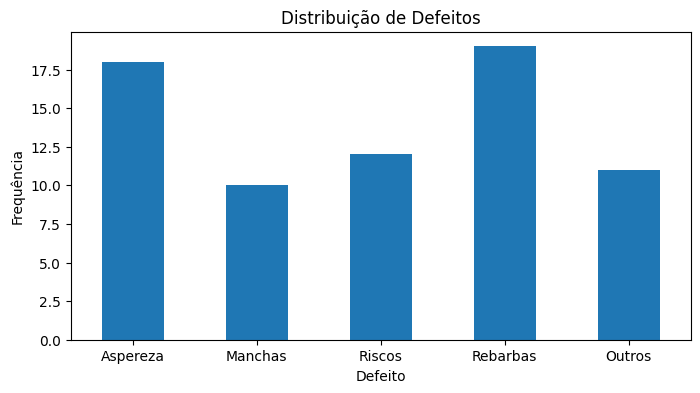

In [ ]:
df_q2 = pd.DataFrame({
    'Defeito': ['Aspereza', 'Manchas', 'Riscos', 'Rebarbas', 'Outros'],
    'fi': [18, 10, 12, 19, 11]
}).set_index('Defeito')

df_q2['fri (%)'] = (df_q2['fi'] / df_q2['fi'].sum()) * 100
df_q2.loc['Total'] = df_q2.sum()

display(df_q2)

df_q2.drop('Total')['fi'].plot.bar(title='Distribuição de Defeitos', ylabel='Frequência', rot=0, figsize=(8,4))
plt.show()

### Questão 3

In [ ]:
dados_q3 = pd.Series([
    2, 14, 18, 22, 26, 32, 45, 59, 66, 80,
    2, 15, 18, 23, 27, 36, 46, 61, 66, 89,
    3, 15, 20, 24, 29, 42, 48, 61, 68, 90,
    10, 16, 21, 25, 29, 44, 52, 61, 75, 92,
    13, 16, 22, 25, 30, 45, 58, 65, 78, 97
])

# Regra de Sturges
k = round(1 + 3.322 * np.log10(len(dados_q3)))
bins = np.linspace(dados_q3.min(), dados_q3.max(), k + 1)

df_freq = pd.cut(dados_q3, bins=bins, include_lowest=True, right=False).value_counts().sort_index().to_frame('fi')
df_freq['fri (%)'] = (df_freq['fi'] / len(dados_q3)) * 100
df_freq['Fi'] = df_freq['fi'].cumsum()

display(df_freq)
print(f"\nMédia: {dados_q3.mean():.2f} | Mediana: {dados_q3.median():.2f} | Desvio Padrão: {dados_q3.std(ddof=1):.2f}")

,fi,fri (%),Fi
"[2.0, 15.571)",8,16.00,8
"[15.571, 29.143)",16,32.00,24
"[29.143, 42.714)",4,8.00,28
"[42.714, 56.286)",6,12.00,34
"[56.286, 69.857)",9,18.00,43
"[69.857, 83.429)",3,6.00,46
"[83.429, 97.0)",3,6.00,49



Média: 40.42 | Mediana: 31.00 | Desvio Padrão: 26.08


### Questão 4

,fi,fri (%),Fi
"[83.4, 85.6)",4,4.88,4
"[85.6, 87.8)",8,9.76,12
"[87.8, 90.0)",23,28.05,35
"[90.0, 92.2)",28,34.15,63
"[92.2, 94.4)",14,17.07,77
"[94.4, 96.6)",3,3.66,80
"[96.6, 98.8)",1,1.22,81
"[98.8, 101.0)",1,1.22,82


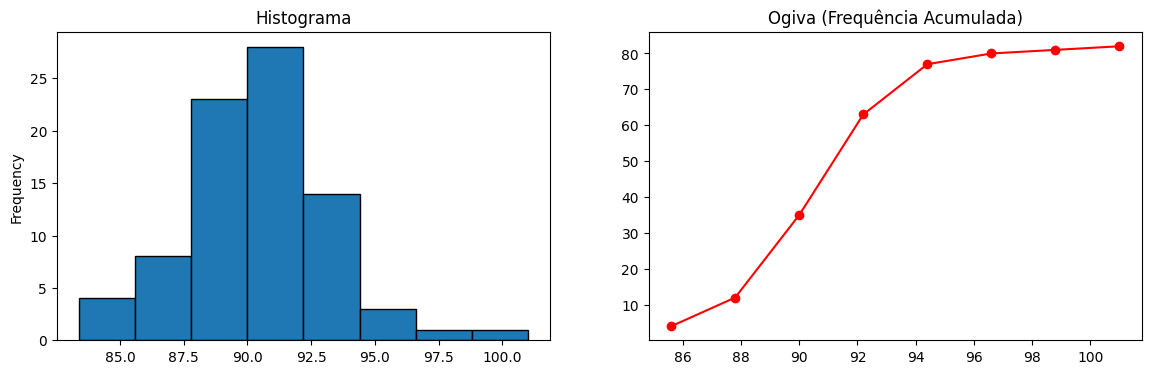

In [ ]:
dados_oct = pd.Series([
    83.4, 87.7, 88.6, 89.8, 90.4, 91.1, 92.2, 93.3, 98.8,
    84.3, 87.8, 88.6, 89.8, 90.4, 91.1, 92.2, 93.3, 100.3,
    84.3, 87.9, 88.7, 89.9, 90.5, 91.1, 92.2, 93.4,
    85.3, 88.2, 88.9, 89.9, 90.6, 91.2, 92.3, 93.7,
    86.7, 88.3, 89.0, 90.0, 90.7, 91.2, 92.6, 94.2,
    86.7, 88.3, 89.2, 90.1, 90.8, 91.5, 92.7, 94.2,
    86.7, 88.3, 89.3, 90.1, 90.9, 91.6, 92.7, 94.4,
    87.4, 88.4, 89.3, 90.1, 91.0, 91.6, 92.7, 94.7,
    87.5, 88.5, 89.6, 90.3, 91.0, 91.8, 93.0, 96.1,
    87.6, 88.5, 89.7, 90.4, 91.0, 91.8, 93.2, 96.5
])

h = 2.2
bins_oct = np.arange(dados_oct.min(), dados_oct.max() + h, h)

df_oct = pd.cut(dados_oct, bins=bins_oct, right=False).value_counts().sort_index().to_frame('fi')
df_oct['fri (%)'] = (df_oct['fi'] / len(dados_oct)) * 100
df_oct['Fi'] = df_oct['fi'].cumsum()

display(df_oct)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dados_oct.plot.hist(bins=bins_oct, ax=axes[0], edgecolor='black', title='Histograma')
axes[1].plot([i.right for i in df_oct.index], df_oct['Fi'], marker='o', color='red')
axes[1].set_title('Ogiva (Frequência Acumulada)')
plt.show()

### Questão 5

In [ ]:
df_pneus = pd.DataFrame({
    'Marca 1': [36925, 45300, 36240, 32100, 37210, 48360, 38200, 33500],
    'Marca 2': [34318, 42280, 35500, 31950, 38015, 47800, 37810, 33215]
})

medias = df_pneus.mean()
display(medias.to_frame('Média (km)'))
print(f"\nO pneu com maior durabilidade média foi a {medias.idxmax()}.")

,Média (km)
Marca 1,38479.38
Marca 2,37611.00



O pneu com maior durabilidade média foi a Marca 1.


### Questão 6

In [ ]:
golos = pd.Series([
    2, 3, 6, 2, 1, 4, 2, 3, 5, 2,
    1, 0, 5, 1, 4, 1, 3, 0, 3, 2,
    2, 1, 5, 2, 0, 1, 6, 2, 3, 3,
    4, 4, 2, 4, 5, 6, 1, 3, 2, 2
])

df_golos = golos.value_counts().sort_index().to_frame('fi')
df_golos['fri (%)'] = (df_golos['fi'] / len(golos)) * 100
df_golos['Fac'] = df_golos['fi'].cumsum()
df_golos.index.name = 'Golos (xi)'

display(df_golos)

,fi,fri (%),Fac
Golos (xi),,,
0,3,7.50,3
1,7,17.50,10
2,11,27.50,21
3,7,17.50,28
4,5,12.50,33
5,4,10.00,37
6,3,7.50,40


### Questões 7, 8 e 9

In [ ]:
# Questão 7
media_final = ((60 * 80) - (20 + 32)) / 58
print(f"Q7 - Nova média: {media_final:.2f}")

# Questão 8
pesos = np.array([2.4, 2.8, 2.4, 2.5, 2.4, 2.7, 2.7, 2.8])
print(f"\nQ8 - Média registada: {pesos.mean():.3f}g")
print(f"Q8 - Média real (corrigida): {pesos.mean() + 0.3:.3f}g")

# Questão 9
N = (1304 - 1184) / (150 - 148)
print(f"\nQ9 - Bastões produzidos: {int(N)}")

Q7 - Nova média: 81.86

Q8 - Média registada: 2.587g
Q8 - Média real (corrigida): 2.887g

Q9 - Bastões produzidos: 60
